In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,bptp terra,sector 37d,1.60,7303.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up...,4,3,3+,7.0,North,Relatively New,2191.0,2000.0,1800.0,0,0,0,0,1,1,139,547.750000
1,flat,dlf express greens,manesar,1.60,6809.0,2350.0,Carpet area: 2350 (218.32 sq.m.),4,6,3+,4.0,North-East,Relatively New,NaN,NaN,2350.0,1,1,0,1,0,0,49,587.500000
2,flat,mapsko royale ville,sector 82,1.12,8000.0,1400.0,Super Built up area 1790(166.3 sq.m.)Built Up ...,3,4,2,6.0,North-West,Relatively New,1790.0,1500.0,1400.0,0,1,0,1,0,1,174,466.666667
3,flat,dlf regal gardens,sector 90,1.25,7340.0,1703.0,Super Built up area 1703(158.21 sq.m.),3,3,3,28.0,North,Moderately Old,1703.0,NaN,NaN,0,1,0,0,0,0,38,567.666667
4,flat,sare green parc,sector 92,0.85,6741.0,1261.0,Built Up area: 1261 (117.15 sq.m.),3,2,2,14.0,NaN,Undefined,NaN,1261.0,NaN,0,0,0,0,0,0,0,420.333333


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
super_built_up_area    1684
built_up_area          1969
carpet_area            1716
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

## Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

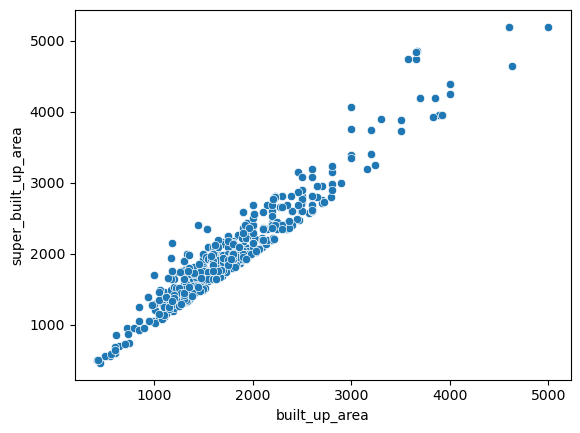

In [6]:
sns.scatterplot(x=df['built_up_area'], y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

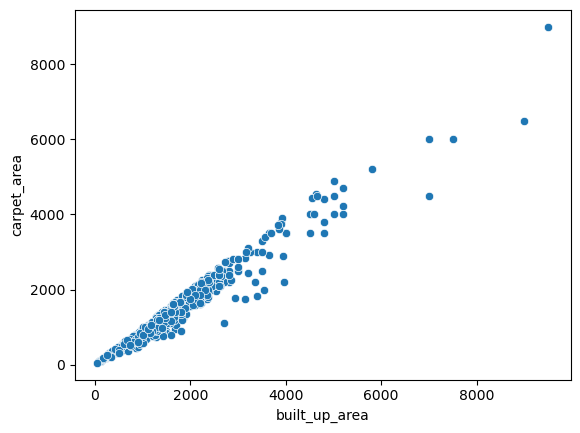

In [7]:
sns.scatterplot(x=df['built_up_area'], y=df['carpet_area'])

In [8]:
(df['super_built_up_area'].isnull() & df['built_up_area'].isnull() & df['carpet_area'].isnull())

0       False
1       False
2       False
3       False
4       False
        ...  
3555    False
3556    False
3557    False
3558    False
3559    False
Length: 3560, dtype: bool

In [9]:
all_present_df = df[~(df['super_built_up_area'].isnull() | df['built_up_area'].isnull() | df['carpet_area'].isnull())]

In [10]:
all_present_df.shape

(532, 24)

In [11]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [12]:
carpet_to_built_up_ration = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [13]:
print(super_to_built_up_ratio, carpet_to_built_up_ration)

1.1063815789473685 0.9


In [14]:
# both present built up null
sbc_df = df[(~df['super_built_up_area'].isnull()) & df['built_up_area'].isnull() & (~df['carpet_area'].isnull())]

In [15]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
12,flat,dlf exclusive floors,sector 43,2.35,14242.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,2,1.0,North-East,Old Property,1650.0,NaN,1405.00,0,0,1,0,0,1,102,550.000000
13,flat,ss almeria,sector 84,1.50,7500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Carpet a...,3,3,3,2.0,NaN,New Property,2000.0,NaN,1700.00,0,1,0,0,0,0,108,666.666667
47,flat,m3m golfestate,sector 65,6.15,18287.0,3363.0,Super Built up area 3363(312.43 sq.m.)Carpet a...,3,3,3,23.0,NaN,Moderately Old,3363.0,NaN,2710.00,1,1,0,0,0,1,60,1121.000000
52,flat,bptp terra,sector 37d,1.80,8215.0,2191.0,Super Built up area 2191(203.55 sq.m.)Carpet a...,4,3,3,18.0,North-West,Relatively New,2191.0,NaN,1860.00,1,1,0,1,0,0,49,547.750000
66,flat,emaar gurgaon greens,sector 102,1.42,8606.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,7.0,East,Relatively New,1650.0,NaN,1022.58,0,1,0,0,0,0,128,550.000000


In [16]:
# sbc_df.fillna({'built_up_area': round((sbc_df['super_built_up_area']/1.106 + sbc_df['carpet_area']/0.9)/2)}, inplace=True)
sbc_df['built_up_area'] = sbc_df['built_up_area'].fillna(round((sbc_df['super_built_up_area']/1.106 + sbc_df['carpet_area']/0.9)/2))

C:\Users\vamsh\AppData\Local\Temp\ipykernel_40768\4150256832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'] = sbc_df['built_up_area'].fillna(round((sbc_df['super_built_up_area']/1.106 + sbc_df['carpet_area']/0.9)/2))


In [17]:
df.update(sbc_df)

In [18]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
super_built_up_area    1684
built_up_area          1548
carpet_area            1716
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [19]:
# sb present c is null built up null
sb_df = df[(~df['super_built_up_area'].isnull()) & df['built_up_area'].isnull() & df['carpet_area'].isnull()]

In [20]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3,flat,dlf regal gardens,sector 90,1.25,7340.0,1703.0,Super Built up area 1703(158.21 sq.m.),3,3,3,28.0,North,Moderately Old,1703.0,NaN,NaN,0,1,0,0,0,0,38,567.666667
9,flat,ss hibiscus,sector 50,6.00,12272.0,4889.0,Super Built up area 4400(408.77 sq.m.),4,3,3,5.0,South-East,Moderately Old,4400.0,NaN,NaN,0,1,0,0,0,0,31,1222.250000
14,flat,vatika the seven lamps,sector 82,0.85,6538.0,1300.0,Super Built up area 1300(120.77 sq.m.),2,2,2,0.0,East,Relatively New,1300.0,NaN,NaN,0,0,0,0,0,1,49,650.000000
23,flat,smriti apartment,sector 56,0.52,10656.0,488.0,Super Built up area 525(48.77 sq.m.),1,1,1,1.0,NaN,Old Property,525.0,NaN,NaN,0,0,0,0,0,0,34,488.000000
24,flat,vatika the seven lamps,sector 82,0.94,6532.0,1439.0,Super Built up area 1435(133.32 sq.m.),2,2,3+,9.0,North,Relatively New,1435.0,NaN,NaN,1,0,0,0,0,1,117,719.500000


In [21]:
sb_df['built_up_area'] = sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.106))

C:\Users\vamsh\AppData\Local\Temp\ipykernel_40768\1339927360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'] = sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.106))


In [22]:
df.update(sb_df)

In [23]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
super_built_up_area    1684
built_up_area           673
carpet_area            1716
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [24]:
# sb null c is present built up null
c_df = df[df['super_built_up_area'].isnull() & df['built_up_area'].isnull() & (~df['carpet_area'].isnull())]

In [25]:
c_df['built_up_area'] = c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9))

C:\Users\vamsh\AppData\Local\Temp\ipykernel_40768\295174752.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'] = c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9))


In [26]:
df.update(c_df)

In [27]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
super_built_up_area    1684
built_up_area             0
carpet_area            1716
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

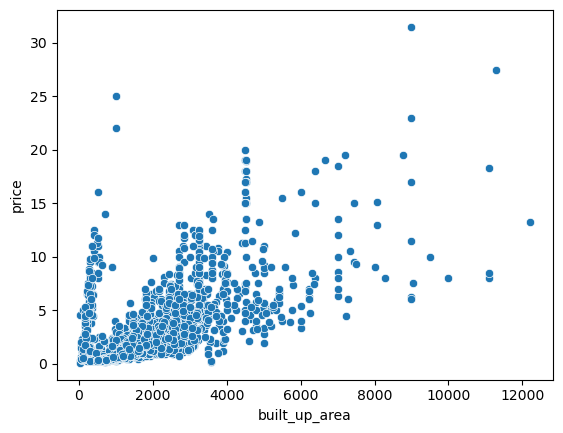

In [28]:
 sns.scatterplot(x=df['built_up_area'], y=df['price'])

In [29]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [31]:
anamoly_df.sample(5)

,price,area,built_up_area
2193,4.25,1620.0,200.0
2840,3.00,1667.0,1653.0
690,4.00,2164.0,1957.0
710,4.31,1350.0,1350.0
336,4.25,1600.0,1778.0


In [32]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [33]:
anamoly_df.sample(5)

,price,area,built_up_area
42,2.65,2047.0,2047.0
277,2.80,2441.0,2441.0
1488,3.25,1070.0,1070.0
2274,2.55,1860.0,1860.0
227,3.25,8829.0,8829.0


In [34]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

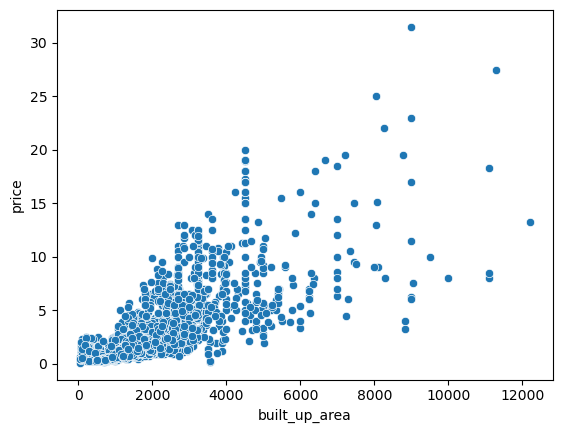

In [36]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [37]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'], inplace=True)

In [38]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp terra,sector 37d,1.60,7303.0,4,3,3+,7.0,North,Relatively New,2000.0,0,0,0,0,1,1,139
1,flat,dlf express greens,manesar,1.60,6809.0,4,6,3+,4.0,North-East,Relatively New,2611.0,1,1,0,1,0,0,49
2,flat,mapsko royale ville,sector 82,1.12,8000.0,3,4,2,6.0,North-West,Relatively New,1500.0,0,1,0,1,0,1,174
3,flat,dlf regal gardens,sector 90,1.25,7340.0,3,3,3,28.0,North,Moderately Old,1540.0,0,1,0,0,0,0,38
4,flat,sare green parc,sector 92,0.85,6741.0,3,2,2,14.0,NaN,Undefined,1261.0,0,0,0,0,0,0,0


In [39]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1012
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

## floorNum

In [40]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
79,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
102,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
366,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
568,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
939,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
1230,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
1574,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
1660,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
1797,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,0,28
1841,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,0,9


In [41]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [43]:
df['floorNum'] = df['floorNum'].fillna(2.0)

In [44]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1012
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [47]:
1012/df.shape[0]

0.2842696629213483

## facing

<Axes: ylabel='count'>

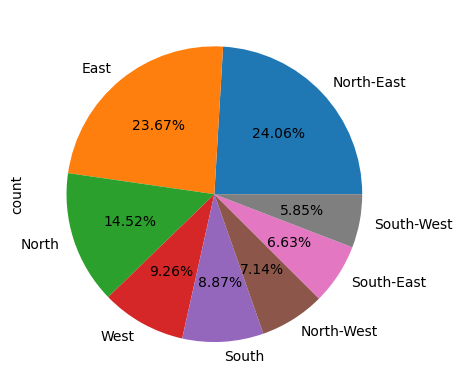

In [45]:
df['facing'].value_counts().plot(kind='pie', autopct='%0.2f%%')

In [48]:
df.drop(columns=['facing'],inplace=True)

In [49]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2500,flat,residency grand,sector 52,5.00,7692.0,5,7,3+,1.0,Moderately Old,5778.0,0,1,0,1,0,0,77
2068,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,3,3,3,0.0,Relatively New,1492.0,1,1,0,0,0,1,159
2581,flat,ss the leaf,sector 85,1.10,6318.0,2,2,3+,3.0,Relatively New,1464.0,0,0,1,0,0,0,143
2705,house,uppal southend,sector 49,3.75,25562.0,2,6,3+,3.0,Moderately Old,1467.0,1,0,0,0,0,1,26
989,flat,ganga apartment,sector 11,0.74,6041.0,3,3,2,0.0,Relatively New,1361.0,0,0,0,0,0,0,62


In [50]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [52]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3075,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,0,0


In [53]:
df.drop(index=[3075],inplace=True)

In [54]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

## agePossession

In [55]:
df['agePossession'].value_counts()

agePossession
Relatively New        1742
New Property           582
Moderately Old         546
Old Property           295
Undefined              291
Under Construction     103
Name: count, dtype: int64

In [57]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,flat,sare green parc,sector 92,0.85,6741.0,3,2,2,14.0,Undefined,1261.0,0,0,0,0,0,0,0
29,flat,essel towers,sector 14,2.20,12500.0,3,4,3+,3.0,Undefined,1956.0,0,0,0,0,0,0,0
31,flat,m3m capital,sector 113,1.83,13969.0,2,2,0,7.0,Undefined,1310.0,0,0,0,0,0,0,68
33,flat,m3m heights,sector 65,2.78,15200.0,3,3,3,44.0,Undefined,1829.0,0,0,0,0,0,0,56
35,house,independent,sector 2,5.00,15385.0,6,6,2,1.0,Undefined,3611.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,flat,czar mahira homes 63a,sector 63a,0.42,7407.0,3,2,2,1.0,Undefined,630.0,0,0,0,0,0,0,0
3464,house,independent,sector 105,0.50,5556.0,2,2,0,1.0,Undefined,100.0,0,0,0,0,0,0,0
3483,flat,hcbs sports ville,sohna road,0.29,3973.0,2,2,1,4.0,Undefined,743.0,0,0,0,0,0,0,0
3496,house,independent,sector 105,1.30,11556.0,3,3,1,1.0,Undefined,1125.0,0,0,0,0,0,0,0


In [59]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # IF mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation, axis=1)

In [61]:
df['agePossession'].value_counts()

agePossession
Relatively New        1866
New Property           627
Moderately Old         584
Old Property           326
Under Construction     103
Undefined               53
Name: count, dtype: int64

In [63]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # IF mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [64]:
df['agePossession'] = df.apply(mode_based_imputation2, axis=1)

In [65]:
df['agePossession'].value_counts()

agePossession
Relatively New        1884
New Property           627
Moderately Old         591
Old Property           329
Under Construction     103
Undefined               25
Name: count, dtype: int64

In [66]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # IF mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [67]:
df['agePossession'] = df.apply(mode_based_imputation3, axis=1)

In [68]:
df['agePossession'].value_counts()

agePossession
Relatively New        1886
New Property           627
Moderately Old         614
Old Property           329
Under Construction     103
Name: count, dtype: int64

In [69]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [70]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv', index=False)